In [10201]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

import warnings
warnings.filterwarnings("ignore") #just to supress warnings

In [10202]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per (target_instances, d), ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col=[0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by=['seed'] + config_cols)

    # aggregate over seeds
    agg = (df.groupby(config_cols, as_index=False)
             .agg(avg_rmse=('rmse', 'mean'),
                  #avg_mae=('val_mae', 'mean'),
                  n_seeds=('seed', 'nunique'),
                  d=('d', 'first')))

    # merge back on config_cols only (minimal fix)
    agg = agg.merge(df, on=config_cols, how='left')

    # sort globally by the fields that determine the ranking
    agg = agg.sort_values(by=['d', 'avg_rmse'], ascending=True)

    # select top-k per (target_instances, d)
    topk_df = agg.groupby(['d'], group_keys=False).head(k)

    # final compact output
    topk_d = topk_df[['d', 'avg_rmse', 'rmse', 'mae']]

    return topk_d, agg




In [10203]:
#Read data (remove v = 0.05 because we chose not to include it)
data_ttb = pd.read_csv('results_200/ttb_LS.csv')
data_ttb = data_ttb[data_ttb['seed'] < 931]

data_xgboost = pd.read_csv('results_200/xgb.csv')
#data_xgboost = data_xgboost[data_xgboost['seed'] < 931]

data_xgboost_warmstart = pd.read_csv('results_200/xgb_warmstart.csv')
#data_xgboost_warmstart = data_xgboost_warmstart[data_xgboost_warmstart['seed'] < 931]

data_xgboost_pooled = pd.read_csv('results_200/xgb_naive.csv')
#data_xgboost_pooled = data_xgboost_pooled[data_xgboost_pooled['seed'] < 931]

data_two_trada = pd.read_csv('results_200/two_trada.csv')


# Here we make final vizes!

<Axes: xlabel='d', ylabel='rmse'>

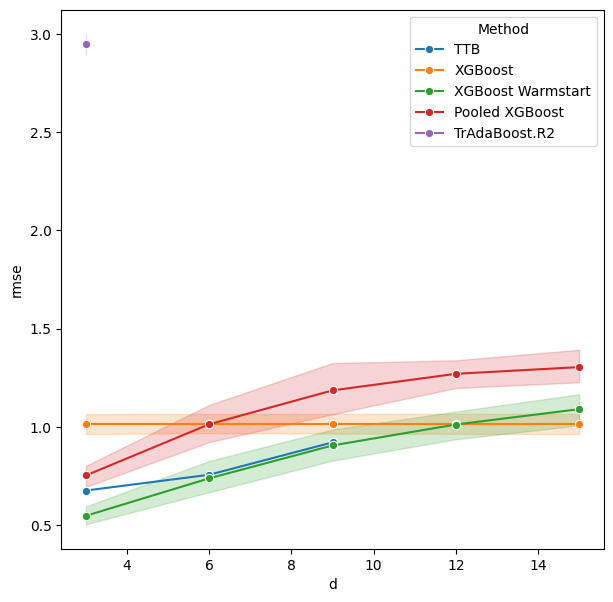

In [10204]:

plt.figure(figsize = (7,7))

import matplotlib as mpl

best_ttb, best_ttb_params = topk_per_d_per_method(
    data_ttb,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=1
)
best_ttb['Method'] = 'TTB'

best_xgboost, best_xgboost_params = topk_per_d_per_method(
    data_xgboost,
    ['d', 'v', 'target_tree_size'], k=10
)
best_xgboost['Method'] = 'XGBoost'

best_xgboost_warmstart, best_xgboost_warmstart_params = topk_per_d_per_method(
    data_xgboost_warmstart,
    ['d', 'v', 'target_tree_size'], k=10
)
best_xgboost_warmstart['Method'] = 'XGBoost Warmstart'

best_xgboost_pooled, best_xgboost_pooled_params = topk_per_d_per_method(
    data_xgboost_pooled,
    ['d', 'v', 'target_tree_size'], k=10
)
best_xgboost_pooled['Method'] = 'Pooled XGBoost'

best_trada, best_trada_params = topk_per_d_per_method(
    data_two_trada,
    ['d', 'lr', 'n_estimators', 'tree_size'], k=10
)
best_trada['Method'] = 'TrAdaBoost.R2'


# create new df for viz
df = pd.concat([best_ttb, best_xgboost])
df = pd.concat([df, best_xgboost_warmstart])
df = pd.concat([df, best_xgboost_pooled])
df = pd.concat([df, best_trada])
sns.lineplot(data=df, x='d', y='rmse', hue='Method', marker = 'o')



In [10205]:
(1.24 + 1.21 + 1.26 + 1.33 + 1.39) / 5

1.286

In [10206]:
best_ttb_params

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,d,Unnamed: 0,seed,method,epochs,val_rmse,val_mae,rmse,mae
51,0.20,3,2,0.01,0.9,0.675937,1,3,50,930,LSTransferTreeBoost,1000,0.676938,0.529350,0.675937,0.536301
25,0.10,2,1,0.01,0.9,0.680418,1,3,24,930,LSTransferTreeBoost,1000,0.669900,0.534116,0.680418,0.537926
60,0.30,2,1,0.00,0.5,0.680845,1,3,61,930,LSTransferTreeBoost,1000,0.680143,0.547907,0.680845,0.536792
43,0.20,2,1,0.01,0.9,0.686930,1,3,42,930,LSTransferTreeBoost,1000,0.682244,0.539428,0.686930,0.540663
33,0.10,3,2,0.01,0.9,0.689212,1,3,32,930,LSTransferTreeBoost,1000,0.703010,0.557525,0.689212,0.536792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,0.05,2,3,0.01,0.9,1.118031,1,9,154,930,LSTransferTreeBoost,1000,1.089301,0.873230,1.118031,0.882766
150,0.05,2,1,0.00,0.5,1.120792,1,9,151,930,LSTransferTreeBoost,1000,1.116243,0.894623,1.120792,0.909499
149,0.05,1,3,0.01,0.9,1.127301,1,9,148,930,LSTransferTreeBoost,1000,1.087991,0.858628,1.127301,0.887381
148,0.05,1,3,0.00,0.5,1.154589,1,9,149,930,LSTransferTreeBoost,1000,1.102341,0.876956,1.154589,0.913887


In [10207]:
best_xgboost_pooled_params

,v,target_tree_size,avg_rmse,n_seeds,d,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae
570,0.25,2.0,0.752809,10,3.0,57,930.0,0.657355,0.526888,0.635509,0.506008
571,0.25,2.0,0.752809,10,3.0,442,931.0,0.742934,0.573692,0.729136,0.565924
572,0.25,2.0,0.752809,10,3.0,827,932.0,0.829374,0.665784,0.796840,0.625169
573,0.25,2.0,0.752809,10,3.0,1212,933.0,0.794317,0.624697,0.794829,0.623659
574,0.25,2.0,0.752809,10,3.0,1597,934.0,0.816664,0.639215,0.774730,0.616991
...,...,...,...,...,...,...,...,...,...,...,...
3085,0.05,1.0,3.222959,10,15.0,2233,935.0,3.945005,3.262432,4.136943,3.380961
3086,0.05,1.0,3.222959,10,15.0,2618,936.0,3.893189,3.144184,3.790356,3.036778
3087,0.05,1.0,3.222959,10,15.0,3003,937.0,1.305557,1.022900,1.308864,1.034766
3088,0.05,1.0,3.222959,10,15.0,3388,938.0,3.452848,2.746802,3.535101,2.774026
